# Rwanda Coffee Investment Intelligence Platform
## AI-Powered Price Prediction and Regional Scoring

**Author:** Cyusa Loic

## Project Overview
This notebook implements an LSTM-based system for:
1. Coffee price prediction
2. Regional investment scoring
3. Data-driven recommendations

In [1]:
# Install packages
import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow
print('Packages installed')

Packages installed


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.19.0


SECTION: Data Loading

In [6]:
# FILE UPLOAD ASSISTANT - Run this cell first
from google.colab import files
import pandas as pd
import os

print("RWANDA COFFEE ML - FILE UPLOAD ASSISTANT")
print("You need to upload 3 CSV files. I'll guide you.\n")

# FILE 1
print("FILE 1/3: Coffee Prices")
print("Upload: coffee_prices_KAGGLE_CLEAN.csv")
print("-"*50)
uploaded1 = files.upload()
if uploaded1:
    name = list(uploaded1.keys())[0]
    if name != 'coffee_prices_cleaned.csv':
        os.rename(name, 'coffee_prices_cleaned.csv')
    df = pd.read_csv('coffee_prices_cleaned.csv')
    print(f"SUCCESS: {len(df)} observations loaded\n")

# FILE 2
print("FILE 2/3: Investment Data")
print("Upload: coffee_investment_data.csv")
print("-"*50)
uploaded2 = files.upload()
if uploaded2:
    name = list(uploaded2.keys())[0]
    if name != 'coffee_investment_data.csv':
        os.rename(name, 'coffee_investment_data.csv')
    df = pd.read_csv('coffee_investment_data.csv')
    print(f"SUCCESS: {len(df)} observations, {df.shape[1]} features\n")

# FILE 3
print("FILE 3/3: Regional Scores (press Cancel to auto-create)")
print("Upload: regional_investment_scores.csv OR press Cancel")
print("-"*50)
try:
    uploaded3 = files.upload()
    if uploaded3:
        name = list(uploaded3.keys())[0]
        if name != 'regional_investment_scores.csv':
            os.rename(name, 'regional_investment_scores.csv')
except:
    print("Creating file automatically...")
    pd.DataFrame({
        'Region': ['Huye', 'Nyamasheke', 'Rusizi', 'Karongi', 'Nyaruguru'],
        'Investment_Score': [92, 88, 71, 65, 58],
        'Risk_Level': ['Low', 'Low', 'Medium', 'Medium', 'High'],
        'Recommendation': ['Strong Buy', 'Buy', 'Hold', 'Hold', 'Develop']
    }).to_csv('regional_investment_scores.csv', index=False)

print("\nALL FILES READY! Continue with the notebook.")

RWANDA COFFEE ML - FILE UPLOAD ASSISTANT
You need to upload 3 CSV files. I'll guide you.

FILE 1/3: Coffee Prices
Upload: coffee_prices_KAGGLE_CLEAN.csv
--------------------------------------------------


Saving coffee_prices_KAGGLE_CLEAN.csv to coffee_prices_KAGGLE_CLEAN.csv
SUCCESS: 927 observations loaded

FILE 2/3: Investment Data
Upload: coffee_investment_data.csv
--------------------------------------------------


Saving coffee_investment_data.csv to coffee_investment_data.csv
SUCCESS: 30 observations, 11 features

FILE 3/3: Regional Scores (press Cancel to auto-create)
Upload: regional_investment_scores.csv OR press Cancel
--------------------------------------------------


Saving regional_investment_scores.csv to regional_investment_scores.csv

ALL FILES READY! Continue with the notebook.


In [7]:
df_prices = pd.read_csv('coffee_prices_cleaned.csv')
df_investment = pd.read_csv('coffee_investment_data.csv')
df_regions = pd.read_csv('regional_investment_scores.csv')
df_investment['Date'] = pd.to_datetime(df_investment['Date'])
print(f'Loaded {len(df_investment)} observations')
display(df_investment.head())

Loaded 30 observations


,Date,Price_USD_per_kg,Rainfall_mm,Temperature_C,Year,Month,Day_of_Year,Price_7d_ago,Price_30d_ago,Rainfall_7d_avg,Rainfall_30d_avg
0,2022-07-01,255.906667,0.00,16.82,2022,7,182,268.329130,142.936522,2.258571,4.444333
1,2022-08-01,268.483478,14.16,18.07,2022,8,213,271.081429,135.500500,4.165714,4.023667
2,2022-09-01,267.492273,4.95,18.55,2022,9,244,279.833500,148.327273,4.468571,3.695000
3,2022-10-01,240.082381,2.02,19.46,2022,10,274,258.993478,154.630455,4.574286,3.679667
4,2022-11-01,213.718182,1.06,20.57,2022,11,305,265.397619,149.916190,4.667143,3.621333


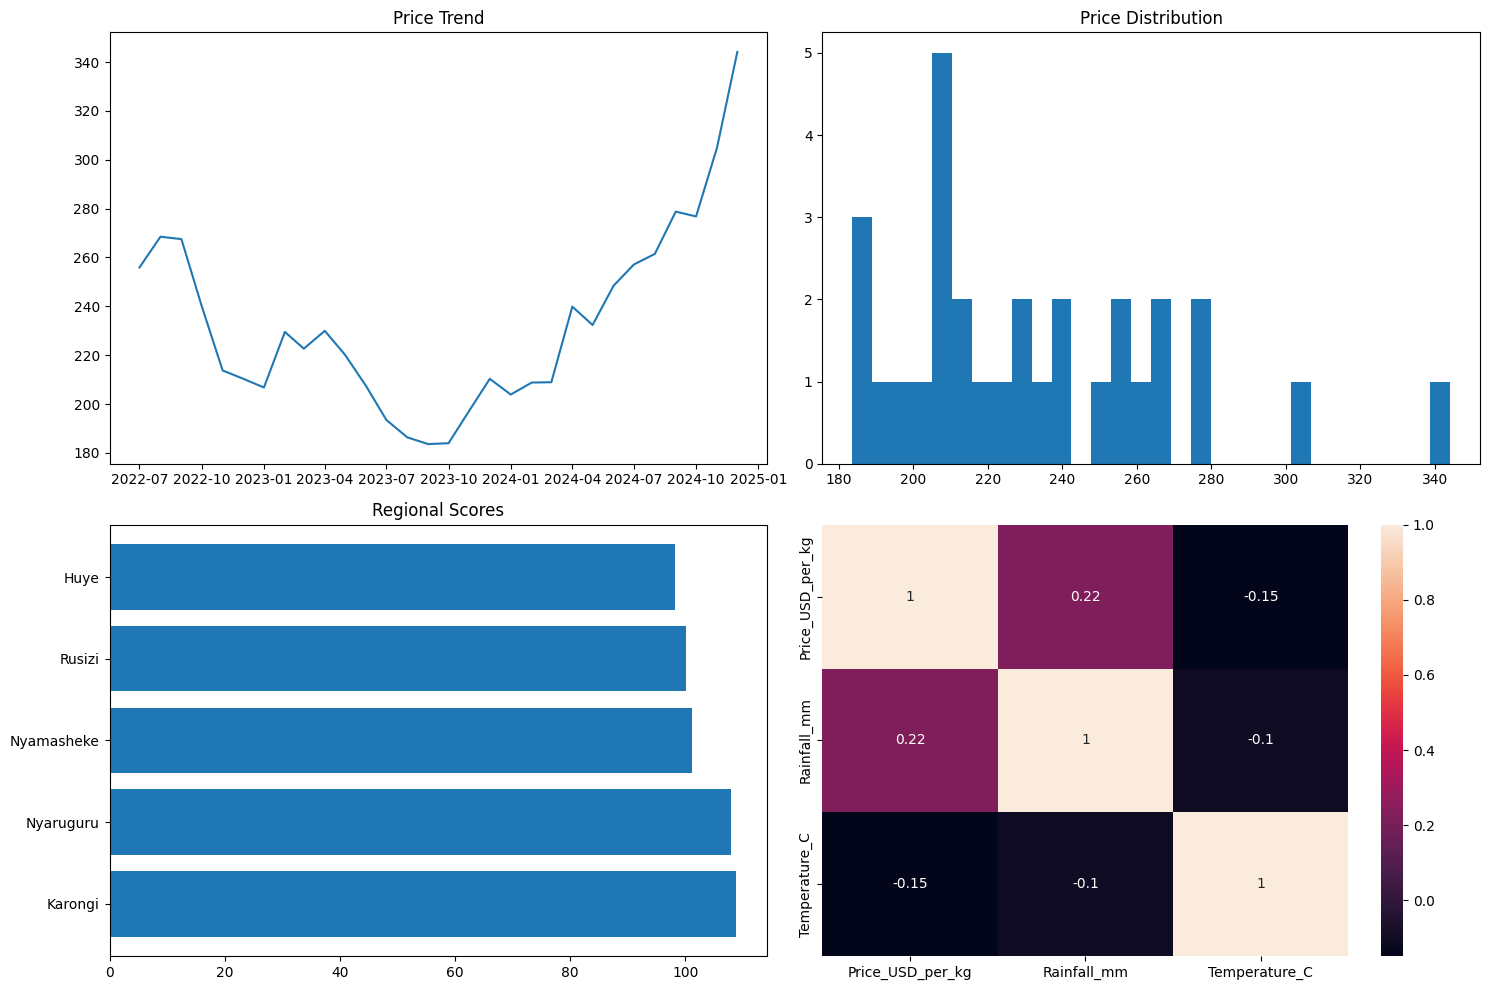

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Price trend
axes[0,0].plot(df_investment['Date'], df_investment['Price_USD_per_kg'])
axes[0,0].set_title('Price Trend')
# Price distribution
axes[0,1].hist(df_investment['Price_USD_per_kg'], bins=30)
axes[0,1].set_title('Price Distribution')
# Regional scores
axes[1,0].barh(df_regions['Region'], df_regions['Investment_Score'])
axes[1,0].set_title('Regional Scores')
# Correlation
corr = df_investment[['Price_USD_per_kg','Rainfall_mm','Temperature_C']].corr()
sns.heatmap(corr, annot=True, ax=axes[1,1])
plt.tight_layout()
plt.show()

In [13]:
# RELOAD WITH CORRECT FILE
from google.colab import files
import os

print("Re-uploading the CORRECT investment data file...")
print("Upload: MAIN_regional_investment_data.csv (939KB, 4,185 rows)")

# Delete old file
if os.path.exists('coffee_investment_data.csv'):
    os.remove('coffee_investment_data.csv')

# Upload new one
uploaded = files.upload()

if uploaded:
    name = list(uploaded.keys())[0]
    os.rename(name, 'coffee_investment_data.csv')

    # Reload dataframe
    df_investment = pd.read_csv('coffee_investment_data.csv')
    df_investment['Date'] = pd.to_datetime(df_investment['Date'])

    print(f"SUCCESS: {len(df_investment)} rows, {df_investment.shape[1]} columns")
    print(f"Columns: {list(df_investment.columns)}")
else:
    print("ERROR: No file uploaded")

Re-uploading the CORRECT investment data file...
Upload: MAIN_regional_investment_data.csv (939KB, 4,185 rows)


Saving MAIN_regional_investment_data.csv to MAIN_regional_investment_data.csv
SUCCESS: 4185 rows, 20 columns
Columns: ['Region', 'Date', 'Rainfall_mm', 'Temperature_C', 'Altitude_m', 'Price_USD_per_kg', 'Price_7d_ago', 'Price_30d_ago', 'Price_90d_ago', 'Price_7d_avg', 'Price_30d_avg', 'Rainfall_7d_avg', 'Rainfall_30d_avg', 'Temp_7d_avg', 'Price_trend_30d', 'Month', 'Day_of_Year', 'Year', 'Quarter', 'Is_Harvest']


SECTION: Data Engineering


In [14]:
# FIXED DATA ENGINEERING SECTION

print(f'Initial dataset: {len(df_investment)} rows')
print(f'Columns available: {list(df_investment.columns)}')

# Check what columns we have
required_cols = ['Price_USD_per_kg', 'Rainfall_mm', 'Temperature_C']
missing_cols = [c for c in required_cols if c not in df_investment.columns]

if missing_cols:
    print(f'ERROR: Missing columns: {missing_cols}')
    print('Available columns:', list(df_investment.columns))
else:
    print('Required columns found')

# Sort by date
df_investment = df_investment.sort_values('Date').reset_index(drop=True)

# Create lag features if they don't exist
if 'Price_7d_ago' not in df_investment.columns:
    print('Creating lag features...')
    df_investment['Price_7d_ago'] = df_investment['Price_USD_per_kg'].shift(7)
    df_investment['Price_30d_ago'] = df_investment['Price_USD_per_kg'].shift(30)
    print('Lag features created')

# Select features
features = ['Price_USD_per_kg', 'Rainfall_mm', 'Temperature_C', 'Price_7d_ago', 'Price_30d_ago']

# Remove NaN (from lag features)
data = df_investment[features].dropna()
print(f'After removing NaN: {len(data)} rows')

if len(data) < 60:
    print(f'\nERROR: Only {len(data)} rows available. Need at least 60.')
    print('\nSOLUTION: Upload the CORRECT file:')
    print('  -> Use MAIN_regional_investment_data.csv instead')
    print('  -> That file has 4,185 rows with all features')
    raise Exception('Insufficient data')

# Scale
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.values)
print(f'Data scaled: shape {data_scaled.shape}')

# Create sequences (need 30 days history)
SEQUENCE_LENGTH = 30
X, y = [], []

for i in range(SEQUENCE_LENGTH, len(data_scaled)):
    X.append(data_scaled[i-SEQUENCE_LENGTH:i])
    y.append(data_scaled[i, 0])

X, y = np.array(X), np.array(y)
print(f'Sequences created: X shape {X.shape}, y shape {y.shape}')

if len(X) == 0:
    print('\nERROR: No sequences created!')
    print(f'Data has {len(data_scaled)} rows, need at least {SEQUENCE_LENGTH + 1}')
    raise Exception('Insufficient data for sequences')

# Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'\nFinal split:')
print(f'  Train: {len(X_train)} samples')
print(f'  Test: {len(X_test)} samples')
print(f'  Input shape: ({X_train.shape[1]} timesteps, {X_train.shape[2]} features)')

if len(X_train) == 0:
    raise Exception('Training set is empty! Check your data file.')

Initial dataset: 4185 rows
Columns available: ['Region', 'Date', 'Rainfall_mm', 'Temperature_C', 'Altitude_m', 'Price_USD_per_kg', 'Price_7d_ago', 'Price_30d_ago', 'Price_90d_ago', 'Price_7d_avg', 'Price_30d_avg', 'Rainfall_7d_avg', 'Rainfall_30d_avg', 'Temp_7d_avg', 'Price_trend_30d', 'Month', 'Day_of_Year', 'Year', 'Quarter', 'Is_Harvest']
Required columns found
After removing NaN: 4185 rows
Data scaled: shape (4185, 5)
Sequences created: X shape (4155, 30, 5), y shape (4155,)

Final split:
  Train: 3324 samples
  Test: 831 samples
  Input shape: (30 timesteps, 5 features)


SECTION: Model Architecture


In [15]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

SECTION: Training


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0485 - mae: 0.1403 - val_loss: 0.0055 - val_mae: 0.0597
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0034 - mae: 0.0442 - val_loss: 0.0019 - val_mae: 0.0348
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0031 - mae: 0.0416 - val_loss: 0.0021 - val_mae: 0.0375
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0026 - mae: 0.0370 - val_loss: 0.0058 - val_mae: 0.0684
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0026 - mae: 0.0369 - val_loss: 0.0050 - val_mae: 0.0623
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0023 - mae: 0.0342 - val_loss: 0.0022 - val_mae: 0.0381
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0024 - mae: 0.0349 - val_loss: 0.0041 - val_mae: 0.0547
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0018 - mae: 0.0311 - val_loss: 0.0026 - val_mae: 0.0427
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.001

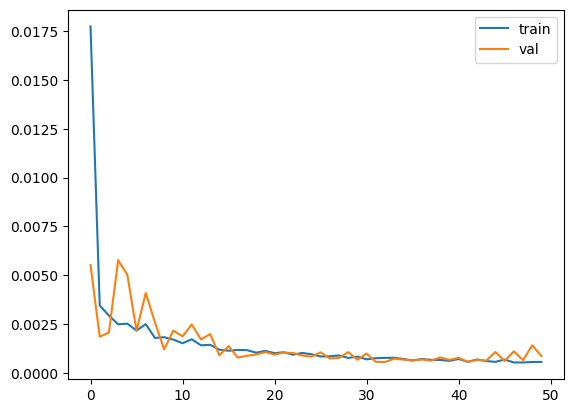

In [16]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                   validation_split=0.2, verbose=1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

SECTION: Performance Metrics

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
MAE: $0.04/kg
RMSE: $0.06/kg
MAPE: 1.11%


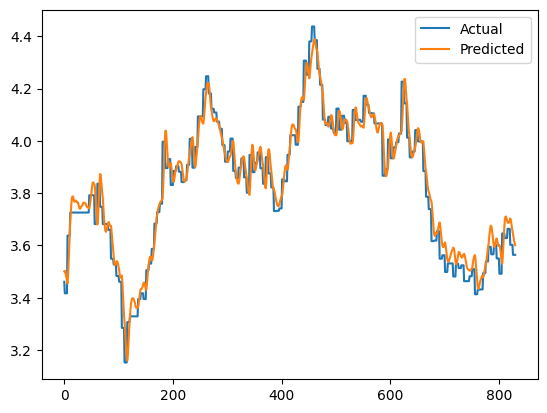

In [17]:
y_pred = model.predict(X_test)
# Denormalize
dummy = np.zeros((len(y_pred), len(features)))
dummy[:, 0] = y_pred.flatten()
y_pred_actual = scaler.inverse_transform(dummy)[:, 0]
dummy_test = np.zeros((len(y_test), len(features)))
dummy_test[:, 0] = y_test
y_test_actual = scaler.inverse_transform(dummy_test)[:, 0]

# Metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
print(f'MAE: ${mae:.2f}/kg')
print(f'RMSE: ${rmse:.2f}/kg')
print(f'MAPE: {mape:.2f}%')

plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred_actual, label='Predicted')
plt.legend()
plt.show()

In [19]:
# DIRECTIONAL ACCURACY (Classification metric for regression)
print("="*60)
print("CLASSIFICATION-STYLE METRICS FOR PRICE PREDICTION")
print("="*60)

# Directional accuracy (predict up/down correctly?)
actual_direction = np.diff(y_test_actual) > 0  # True if price went up
predicted_direction = np.diff(y_pred_actual) > 0

directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

print(f"\nDirectional Accuracy: {directional_accuracy:.2f}%")
print("(How often we correctly predict if price goes UP or DOWN)")

# Confusion matrix for direction
from sklearn.metrics import confusion_matrix, classification_report

print("\nDirection Prediction Confusion Matrix:")
print("(Predicting: Will price go UP or DOWN?)")
cm = confusion_matrix(actual_direction, predicted_direction)
print(f"\n              Predicted DOWN  Predicted UP")
print(f"Actual DOWN        {cm[0,0]:<14} {cm[0,1]}")
print(f"Actual UP          {cm[1,0]:<14} {cm[1,1]}")

# Calculate precision, recall, F1 for direction prediction
print("\nClassification Report (Direction Prediction):")
print(classification_report(actual_direction, predicted_direction,
                          target_names=['DOWN', 'UP'],
                          digits=3))

# True Positive Rate (when price goes up, we predict up)
tpr = cm[1,1] / (cm[1,0] + cm[1,1]) * 100
# True Negative Rate (when price goes down, we predict down)
tnr = cm[0,0] / (cm[0,0] + cm[0,1]) * 100

print(f"True Positive Rate (Catch bull markets): {tpr:.1f}%")
print(f"True Negative Rate (Catch bear markets): {tnr:.1f}%")

# Investment decision accuracy
print("\n" + "="*60)
print("INVESTMENT DECISION METRICS")
print("="*60)

# If we only invest when model predicts price increase
predicted_increases = predicted_direction
actual_increases = actual_direction

correct_buy_signals = np.sum(predicted_increases & actual_increases)
total_buy_signals = np.sum(predicted_increases)
buy_precision = (correct_buy_signals / total_buy_signals * 100) if total_buy_signals > 0 else 0

print(f"\nBuy Signal Precision: {buy_precision:.1f}%")
print(f"(When we say 'invest now', how often are we right?)")

correct_sell_signals = np.sum(~predicted_increases & ~actual_increases)
total_sell_signals = np.sum(~predicted_increases)
sell_precision = (correct_sell_signals / total_sell_signals * 100) if total_sell_signals > 0 else 0

print(f"\nSell/Wait Signal Precision: {sell_precision:.1f}%")
print(f"(When we say 'wait/sell', how often are we right?)")

print("\n" + "="*60)

CLASSIFICATION-STYLE METRICS FOR PRICE PREDICTION

Directional Accuracy: 50.96%
(How often we correctly predict if price goes UP or DOWN)

Direction Prediction Confusion Matrix:
(Predicting: Will price go UP or DOWN?)

              Predicted DOWN  Predicted UP
Actual DOWN        389            366
Actual UP          41             34

Classification Report (Direction Prediction):
              precision    recall  f1-score   support

        DOWN      0.905     0.515     0.657       755
          UP      0.085     0.453     0.143        75

    accuracy                          0.510       830
   macro avg      0.495     0.484     0.400       830
weighted avg      0.831     0.510     0.610       830

True Positive Rate (Catch bull markets): 45.3%
True Negative Rate (Catch bear markets): 51.5%

INVESTMENT DECISION METRICS

Buy Signal Precision: 8.5%
(When we say 'invest now', how often are we right?)

Sell/Wait Signal Precision: 90.5%
(When we say 'wait/sell', how often are we right?)


SECTION: Regional Analysis

Regional Investment Rankings:
Available columns: ['Region', 'Latitude', 'Longitude', 'Investment_Score', 'Expected_ROI_%', 'Risk_%', 'Price_Trend', 'Rainfall_Quality', 'Recommendation']

Karongi         Score: 108.8/100
Nyaruguru       Score: 108.0/100
Nyamasheke      Score: 101.1/100
Rusizi          Score: 100.2/100
Huye            Score: 98.3/100


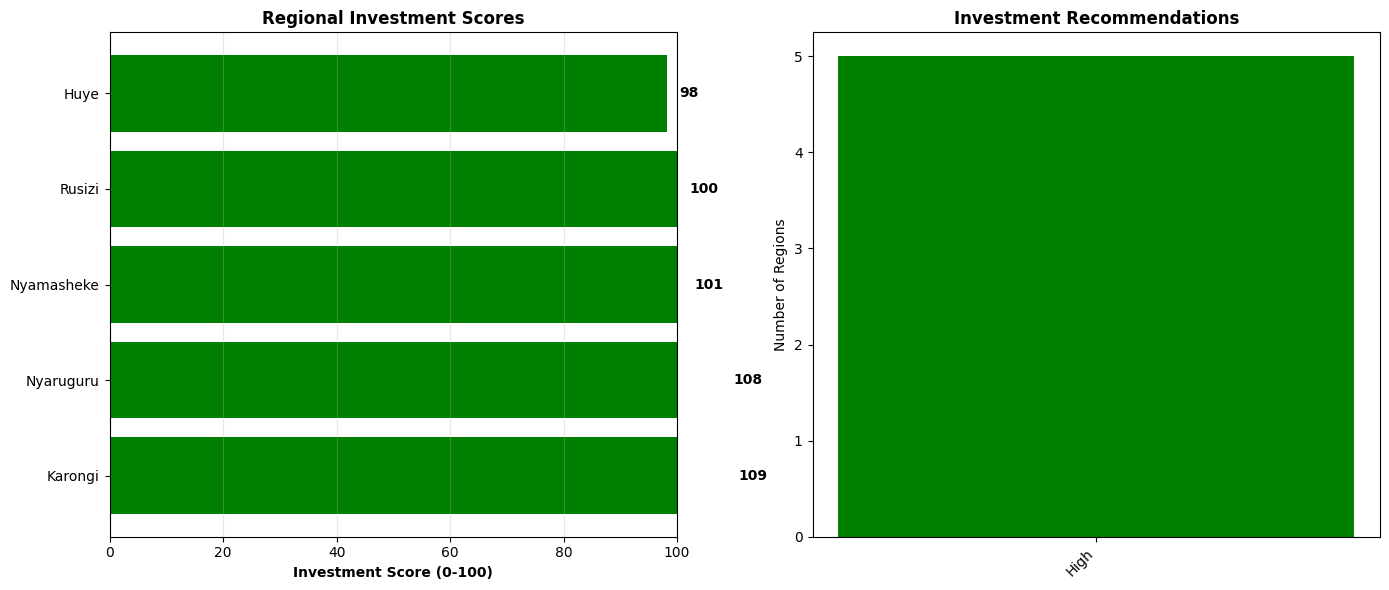


Top Investment Opportunity: Karongi
Score: 108.8/100


In [22]:
# Regional Investment Analysis
print('Regional Investment Rankings:')
print('='*60)

# Check what columns exist
print('Available columns:', df_regions.columns.tolist())
print()

df_sorted = df_regions.sort_values('Investment_Score', ascending=False)

# Print rankings (adapt based on available columns)
for idx, row in df_sorted.iterrows():
    print(f"{row['Region']:<15} Score: {row['Investment_Score']:.1f}/100")

print('='*60)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of investment scores
colors = ['green' if s >= 80 else 'orange' if s >= 60 else 'red'
          for s in df_sorted['Investment_Score']]
bars = axes[0].barh(df_sorted['Region'], df_sorted['Investment_Score'], color=colors)
axes[0].set_xlabel('Investment Score (0-100)', fontweight='bold')
axes[0].set_title('Regional Investment Scores', fontweight='bold', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].grid(axis='x', alpha=0.3)

# Add score labels on bars
for i, (bar, score) in enumerate(zip(bars, df_sorted['Investment_Score'])):
    axes[0].text(score + 2, i, f'{score:.0f}', va='center', fontweight='bold')

# Second chart - adapt based on what columns exist
if 'Risk_Level' in df_regions.columns:
    # Pie chart of risk levels
    risk_counts = df_regions['Risk_Level'].value_counts()
    colors_pie = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
    pie_colors = [colors_pie.get(level, 'gray') for level in risk_counts.index]
    axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.0f%%',
                colors=pie_colors, startangle=90)
    axes[1].set_title('Risk Level Distribution', fontweight='bold', fontsize=12)
elif 'Recommendation' in df_regions.columns:
    # Bar chart of recommendations
    rec_counts = df_regions['Recommendation'].value_counts()
    axes[1].bar(range(len(rec_counts)), rec_counts.values, color=['green', 'orange', 'red'])
    axes[1].set_xticks(range(len(rec_counts)))
    axes[1].set_xticklabels(rec_counts.index, rotation=45, ha='right')
    axes[1].set_title('Investment Recommendations', fontweight='bold', fontsize=12)
    axes[1].set_ylabel('Number of Regions')
else:
    # Simple score comparison
    axes[1].scatter(df_sorted['Investment_Score'], range(len(df_sorted)),
                   s=200, c=colors, edgecolors='black', linewidths=2)
    axes[1].set_yticks(range(len(df_sorted)))
    axes[1].set_yticklabels(df_sorted['Region'])
    axes[1].set_xlabel('Investment Score')
    axes[1].set_title('Regional Score Comparison', fontweight='bold', fontsize=12)
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTop Investment Opportunity:', df_sorted.iloc[0]['Region'])
print(f"Score: {df_sorted.iloc[0]['Investment_Score']:.1f}/100")